#Gradient Boosting Regressor - XGBoost Regressor

In [1]:
# 1️⃣ imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing        # real‑world regression data
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import GradientBoostingRegressor        # model 1
from xgboost import XGBRegressor                              # model 2 (external lib)

# (optional) ignore harmless warnings to keep output clean
import warnings, sys, os
warnings.filterwarnings("ignore")


In [2]:
# 2️⃣ fetch dataset
cal = fetch_california_housing(as_frame=True)
df  = cal.frame          # pandas DataFrame

print(df.head())         # preview first rows
print(f"\nShape: {df.shape}")
print("\nMissing values:\n", df.isna().sum())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape: (20640, 9)

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [3]:
# 3️⃣ keep reproducibility via random_state
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [4]:
# 4️⃣ create & fit basic model
gbr = GradientBoostingRegressor(
        n_estimators=200,      # total boosted trees
        learning_rate=0.05,   # shrinkage (smaller ⇒ larger n_estimators usually)
        max_depth=3,          # individual tree depth
        random_state=42)

gbr.fit(X_train, y_train)

# 4b️⃣ evaluate
pred_gbr = gbr.predict(X_test)
mae_gbr  = mean_absolute_error(y_test, pred_gbr)
mse_gbr  = mean_squared_error(y_test, pred_gbr)
r2_gbr   = r2_score(y_test, pred_gbr)

print(f"Gradient Boosting  MAE: {mae_gbr:.3f}")
print(f"Gradient Boosting  MSE: {mse_gbr:.3f}")
print(f"Gradient Boosting   R²: {r2_gbr :.3f}")


Gradient Boosting  MAE: 0.369
Gradient Boosting  MSE: 0.291
Gradient Boosting   R²: 0.778


In [5]:
# 5️⃣ create & fit (reasonable defaults for tabular data)
xgb = XGBRegressor(
        n_estimators=500,       # number of boosting rounds
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,          # row sampling to combat overfit
        colsample_bytree=0.8,   # column sampling
        objective='reg:squarederror',
        n_jobs=-1,              # utilise all CPU cores
        random_state=42)

xgb.fit(X_train, y_train)

# 5b️⃣ evaluate
pred_xgb = xgb.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, pred_xgb)
mse_xgb  = mean_squared_error(y_test, pred_xgb)
r2_xgb   = r2_score(y_test, pred_xgb)

print(f"XGBoost          MAE: {mae_xgb:.3f}")
print(f"XGBoost          MSE: {mse_xgb:.3f}")
print(f"XGBoost           R²: {r2_xgb :.3f}")


XGBoost          MAE: 0.317
XGBoost          MSE: 0.224
XGBoost           R²: 0.829


               Model       MAE       MSE        R2
0  Gradient Boosting  0.368997  0.291214  0.777768
1            XGBoost  0.316693  0.224362  0.828785


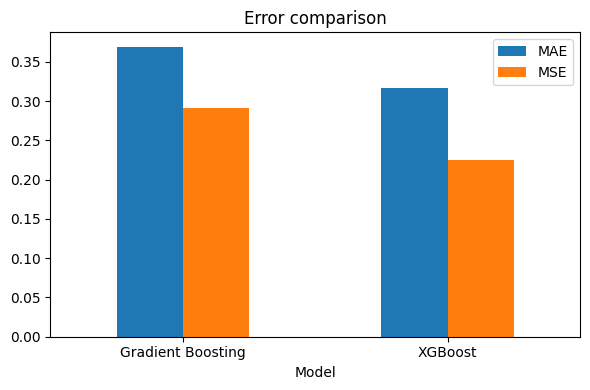

In [6]:
results = pd.DataFrame({
    'Model' : ['Gradient Boosting', 'XGBoost'],
    'MAE'   : [mae_gbr, mae_xgb],
    'MSE'   : [mse_gbr, mse_xgb],
    'R2'    : [r2_gbr , r2_xgb ]
})
print(results)

# quick bar chart (lower MAE/MSE better, higher R² better)
results.set_index('Model')[['MAE','MSE']].plot(kind='bar', rot=0, figsize=(6,4))
plt.title("Error comparison")
plt.tight_layout()
plt.show()



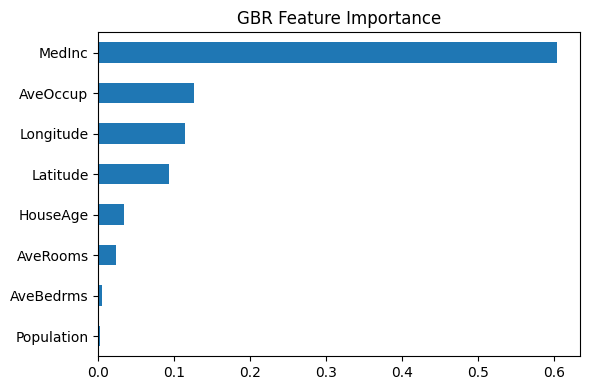

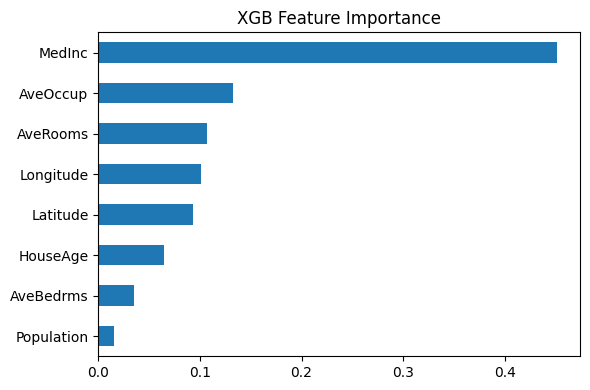

In [7]:
#Feature importance
#A > GBR (scikit‑learn)

gbr_imp = pd.Series(gbr.feature_importances_, index=X.columns).sort_values()
gbr_imp.plot(kind='barh', figsize=(6,4))
plt.title("GBR Feature Importance")
plt.tight_layout()
plt.show()

#B > XGB (built‑in plot or pandas)

xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
xgb_imp.plot(kind='barh', figsize=(6,4))
plt.title("XGB Feature Importance")
plt.tight_layout()
plt.show()




In [8]:
#Basic hyper‑parameter tuning for XGB

param_grid = {
    'n_estimators': [300, 500],
    'max_depth'  : [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample'     : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid = GridSearchCV(
        XGBRegressor(
            objective='reg:squarederror',
            n_jobs=-1,
            random_state=42),
        param_grid,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)


#Re‑train xgb_best = XGBRegressor(**grid.best_params_, objective='reg:squarederror', n_jobs=-1) on the full training set if you want a final tuned model.

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 1.0}
Best CV MAE: 0.3013296626204452


#Key take‑aways

| Point                | Gradient Boosting (GBR)                                    | XGBoost                                          |
| -------------------- | ---------------------------------------------------------- | ------------------------------------------------ |
| Base algorithm       | Sequential additive trees (Friedman, 2001)                 | Gradient boosting with extra optimisations       |
| Training speed       | Fast for modest `n_estimators`                             | Faster (hist‑based), parallel, big hyper‑grid    |
| Regularisation knobs | `learning_rate`, `n_estimators`, `max_depth`, `subsample`‡ | Same plus **`gamma`, `lambda`, `alpha`** (L1/L2) |
| Handles missing?     | No (needs imputation)                                      | Yes (learns default path)                        |
| Interpretability     | Feature importances, partial‑dependence                    | Same + SHAP/TreeExplainer (external libs)        |
| Typical accuracy     | Good                                                       | Often state‑of‑the‑art for tabular               |
